In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.makedirs('/content/drive/MyDrive/AI4Alzheimers/data', exist_ok=True)

In [7]:
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Personal',
 'CV',
 'Primrose',
 'Copy of BCS306a super important -22SCHEME (1) (1) (1).pdf',
 'Analysis and Design of Algorithms IV A',
 'Classroom',
 'Samyog 2025',
 'Screenshot 2025-05-20 112159.png',
 'Anish_Kulkarni_CV',
 'Sunil',
 'Anish_Kulkarni_CV (5).pdf',
 'Anish_Kulkarni_CV (4).pdf',
 'Anish_Kulkarni_CV (3).pdf',
 'Anish_Kulkarni_CV (1).pdf',
 'Anish_Kulkarni_CV.pdf',
 'HadoopVitrualBox Installation Steps.pdf',
 'Certifications',
 'Anish_Kulkarni_CV (2) (2).pdf',
 'Anish_Kulkarni_CV (2) (1).pdf',
 'Anish_Kulkarni_CV (2).pdf',
 'Chapter 6 – TESTING.gdoc',
 'AI4Alzheimers']

In [2]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Personal',
 'CV',
 'Primrose',
 'Copy of BCS306a super important -22SCHEME (1) (1) (1).pdf',
 'Analysis and Design of Algorithms IV A',
 'Classroom',
 'Samyog 2025',
 'Screenshot 2025-05-20 112159.png',
 'Anish_Kulkarni_CV',
 'Sunil',
 'Anish_Kulkarni_CV (5).pdf',
 'Anish_Kulkarni_CV (4).pdf',
 'Anish_Kulkarni_CV (3).pdf',
 'Anish_Kulkarni_CV (1).pdf',
 'Anish_Kulkarni_CV.pdf',
 'HadoopVitrualBox Installation Steps.pdf',
 'Certifications',
 'Anish_Kulkarni_CV (2) (2).pdf',
 'Anish_Kulkarni_CV (2) (1).pdf',
 'Anish_Kulkarni_CV (2).pdf',
 'Chapter 6 – TESTING.gdoc']

In [3]:
!pip install torch torchvision pandas numpy matplotlib seaborn scikit-learn

In [4]:
import torch
import pandas as pd
import numpy as np

print(torch.__version__)
print(pd.__version__)

2.9.0+cpu
2.2.2


In [8]:
import os

os.listdir('/content/drive/MyDrive/AI4Alzheimers/data')

['test.parquet', 'train.parquet']

In [9]:
import pandas as pd

train = pd.read_parquet('/content/drive/MyDrive/AI4Alzheimers/data/train.parquet')
test = pd.read_parquet('/content/drive/MyDrive/AI4Alzheimers/data/test.parquet')

In [10]:
train.shape

(5120, 2)

In [11]:
train.columns

Index(['image', 'label'], dtype='object')

In [13]:
train.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2


In [14]:
train['label'].value_counts()

,count
label,
2,2566
3,1781
0,724
1,49


### Dataset Overview

- Number of classes: 4 (labels 0, 1, 2, 3)
- Class distribution:
  - Class 2: 2566 samples
  - Class 3: 1781 samples
  - Class 0: 724 samples
  - Class 1: 49 samples
- Observation: Dataset is highly imbalanced, especially class 1.

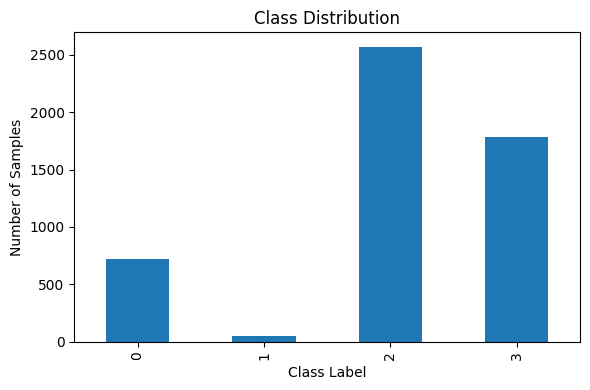

In [15]:
import matplotlib.pyplot as plt

class_counts = train['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

In [16]:
train.iloc[0]

,0
image,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
label,2


### Data Format Inspection

- Images are stored as raw JPEG bytes inside the parquet file.
- Each row contains:
  - `image`: byte-encoded JPEG image
  - `label`: integer class label (0–3)
- Images will require decoding before preprocessing and model training.


### Visual Analysis

The dataset shows clear class imbalance, with significantly fewer samples in the Moderate Demented class. This imbalance may bias model predictions toward majority classes if not handled properly.


In [18]:
import os
os.makedirs('outputs', exist_ok=True)

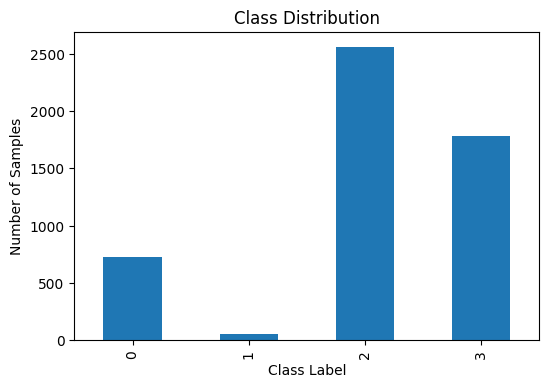

In [35]:
import matplotlib.pyplot as plt

class_counts = train['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')

plt.savefig("outputs/class_distribution.png", bbox_inches="tight")
plt.show()

In [30]:
os.listdir('outputs')

['class_distribution.png']

In [31]:
import os
os.makedirs("outputs", exist_ok=True)

In [36]:
import os
os.listdir("outputs")

['baseline_loss_curve.png', 'class_distribution.png']